In [1]:
from pathlib import Path
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.patches as mpatches
from itertools import cycle
from scipy.io import savemat, loadmat


In [2]:
#subject_dir = Path(r"/home/charlotte/Documents/Tesi/Motoneuron_Synergies_Driven_Gesture_Prediction/glove_sample_subj_01_trial_01")
subject_dir = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_sample_subj_01_trial_01")
# Record WFDB: .hea (header) and .dat (dati).
hea_files = sorted(subject_dir.glob("*.hea"))
print("File .hea trovati:")
for f in hea_files:
    print(f.name)

# Choose the first .hea file (assuming there's only one record per trial)
record_base = hea_files[0].with_suffix("")  

# Read record: wfdb load automatically the .dat file
rec = wfdb.rdrecord(str(record_base))

print("\nName Angles Glove:")
for i, name in enumerate(rec.sig_name):
    print(i, name)

data = rec.p_signal
print("\nShape dati:", data.shape)
print("Sampling Frequency (I think here there is an error in the file, paper explicitly says 200 Hz):", rec.fs)

File .hea trovati:
hdkw_kin_exp03_subj01_1_glove.hea

Name Angles Glove:
0 TN
1 TF
2 T&I
3 IN
4 IF
5 I&M
6 MN
7 MF
8 M&R
9 RN
10 RF
11 R&P
12 PN
13 PF

Shape dati: (37400, 14)
Sampling Frequency (I think here there is an error in the file, paper explicitly says 200 Hz): 2000


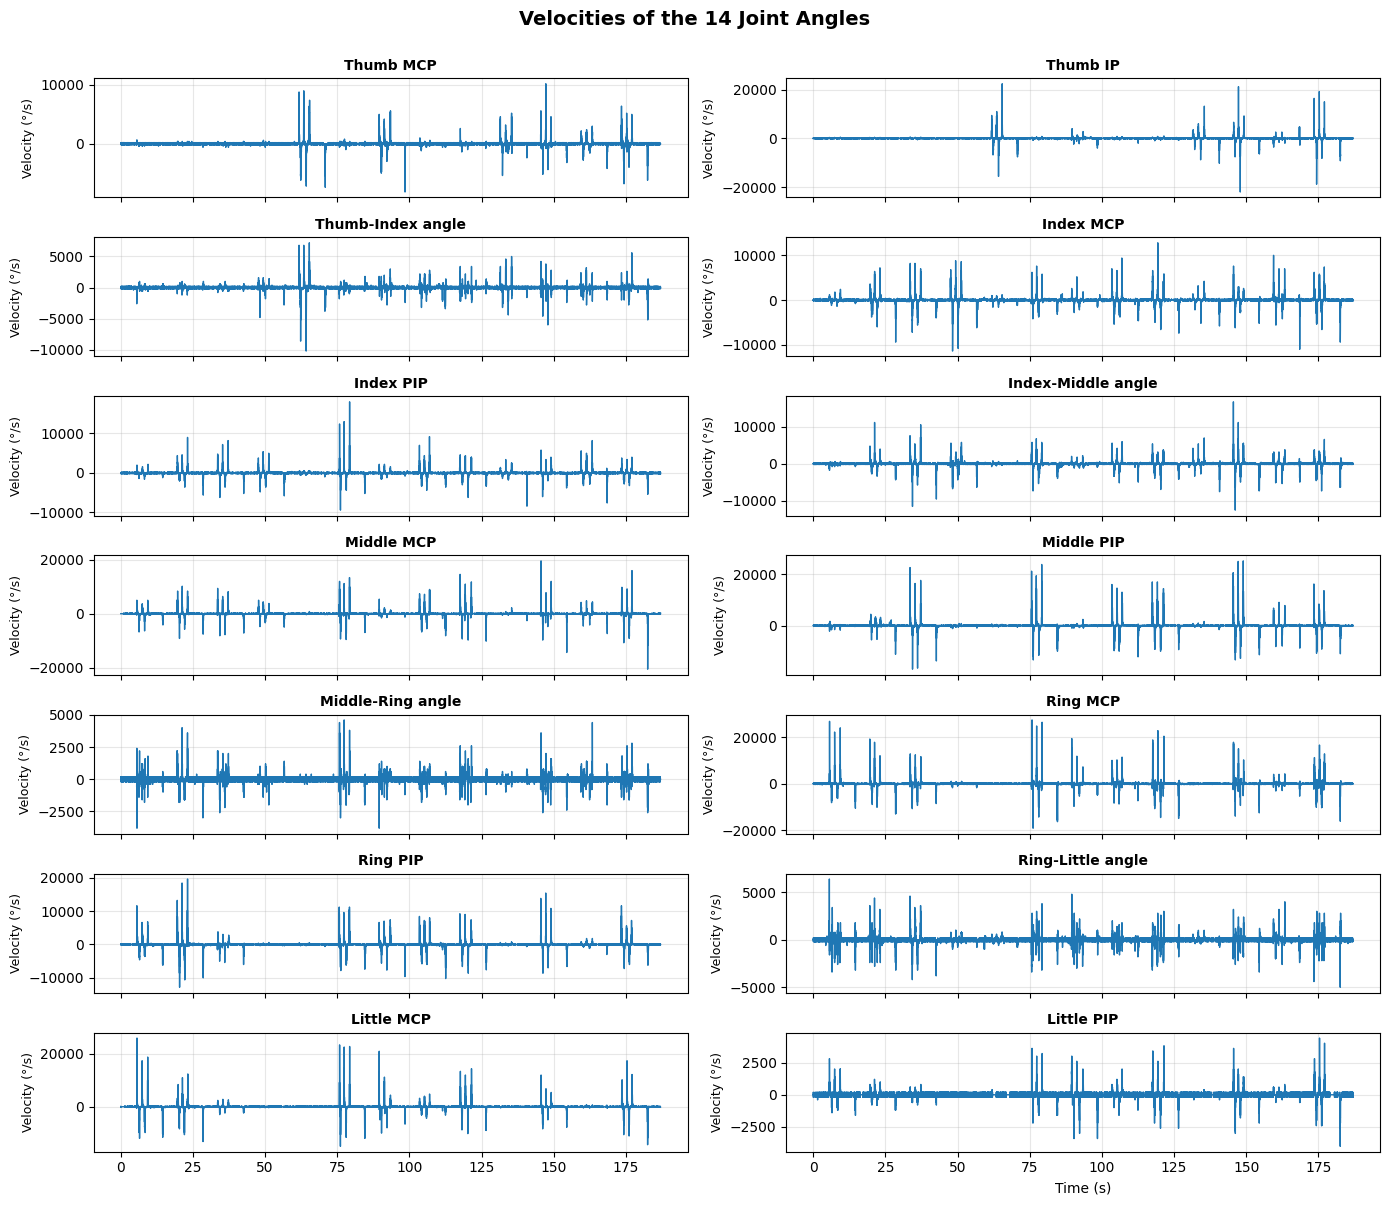

Total duration: 186.99 seconds
Number of velocity samples: 37399


In [3]:
# Compute velocities (derivative of the signal values of these channels for finger flexion and abduction).
# These are not angles, so velocity is in signal units/s, not degrees/s.

fs = 200  
dt = 1 / fs
velocities = np.diff(data, axis=0) / dt

time = np.arange(velocities.shape[0]) / fs

# Channel Mapping
channel_names = [
    "Thumb MCP", "Thumb IP", "Thumb-Index angle",
    "Index MCP", "Index PIP", "Index-Middle angle",
    "Middle MCP", "Middle PIP", "Middle-Ring angle",
    "Ring MCP", "Ring PIP", "Ring-Little angle",
    "Little MCP", "Little PIP"
]

# Plot: Signal gloves angles velocities for all 14 channels.
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ch in range(14):
    axes[ch].plot(time, velocities[:, ch], linewidth=1)
    axes[ch].set_title(channel_names[ch], fontsize=10, fontweight='bold')
    axes[ch].set_ylabel('Velocity (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.suptitle('Velocities of the 14 Joint Angles', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"Total duration: {time[-1]:.2f} seconds")
print(f"Number of velocity samples: {velocities.shape[0]}")

## Define the Rig in Unity in order to choose wheter preprocessing the angular information

In [4]:
df = pd.DataFrame(data, columns=channel_names)
df.to_csv("glove_data.csv", index=False)

In [5]:
record_base = r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_sample_subj_01_trial_01"   # without .hea/.dat

channel_names = [
    "Thumb_MCP", "Thumb_IP", "Thumb_Index_abd",
    "Index_MCP", "Index_PIP", "Index_Middle_abd",
    "Middle_MCP", "Middle_PIP", "Middle_Ring_abd",
    "Ring_MCP", "Ring_PIP", "Ring_Little_abd",
    "Little_MCP", "Little_PIP"
]

# Practical mapping of normalized signal values to degrees for Unity.
flexion_channels = {
    "Thumb_MCP": 60.0,
    "Thumb_IP": 80.0,
    "Index_MCP": 75.0,
    "Index_PIP": 95.0,
    "Middle_MCP": 75.0,
    "Middle_PIP": 100.0,
    "Ring_MCP": 75.0,
    "Ring_PIP": 100.0,
    "Little_MCP": 75.0,
    "Little_PIP": 95.0,
}

abduction_channels = {
    "Thumb_Index_abd": 30.0,
    "Index_Middle_abd": 20.0,
    "Middle_Ring_abd": 20.0,
    "Ring_Little_abd": 25.0,
}

# Signs to decide if some fingers rotate in the opposite direction in Unity
sign_map = {
    "Thumb_MCP": 1.0,
    "Thumb_IP": 1.0,
    "Thumb_Index_abd": 1.0,
    "Index_MCP": 1.0,
    "Index_PIP": 1.0,
    "Index_Middle_abd": 1.0,
    "Middle_MCP": 1.0,
    "Middle_PIP": 1.0,
    "Middle_Ring_abd": 1.0,
    "Ring_MCP": 1.0,
    "Ring_PIP": 1.0,
    "Ring_Little_abd": 1.0,
    "Little_MCP": 1.0,
    "Little_PIP": 1.0,
}


# LOAD DATA 
if data.shape[1] != 14:
    raise ValueError(f"Expected 14 glove channels, found {data.shape[1]}")

n_samples = data.shape[0]
time_s = np.arange(n_samples) / fs

raw_df = pd.DataFrame(data, columns=channel_names)
raw_df.insert(0, "time_s", time_s)

# === MIN-MAX NORMALIZATION PER CHANNEL ===
mins = raw_df[channel_names].min(axis=0)
maxs = raw_df[channel_names].max(axis=0)
ranges = (maxs - mins).replace(0, 1.0)

norm_df = raw_df.copy()
norm_df[channel_names] = (raw_df[channel_names] - mins) / ranges

# clamp safety
norm_df[channel_names] = norm_df[channel_names].clip(0.0, 1.0)

# UNITY DEGREES CSV 
unity_df = pd.DataFrame()
unity_df["time_s"] = time_s

for ch in channel_names:
    vals = norm_df[ch].values

    if ch in flexion_channels:
        deg = vals * flexion_channels[ch]
    elif ch in abduction_channels:
        deg = (vals - 0.5) * abduction_channels[ch]
    else:
        deg = vals * 90.0

    deg = sign_map[ch] * deg
    unity_df[ch] = deg

# CALIBRATION 
calib_rows = []
for ch in channel_names:
    calib_rows.append({
        "channel": ch,
        "raw_min": float(mins[ch]),
        "raw_max": float(maxs[ch]),
        "range": float(ranges[ch]),
        "unity_mapping": (
            f"norm*{flexion_channels[ch]:.1f}"
            if ch in flexion_channels
            else f"(norm-0.5)*{abduction_channels[ch]:.1f}"
        ),
        "sign": sign_map[ch]
    })

calib_df = pd.DataFrame(calib_rows)

# SAVE 
out_dir = Path(record_base).parent
raw_path = out_dir / "glove_raw.csv"
norm_path = out_dir / "glove_norm01.csv"
unity_path = out_dir / "glove_unity_deg.csv"
calib_path = out_dir / "glove_calibration.csv"

#raw_df.to_csv(raw_path, index=False)
#norm_df.to_csv(norm_path, index=False)
#unity_df.to_csv(unity_path, index=False)
#calib_df.to_csv(calib_path, index=False)

# print(f"Saved: {raw_path}")
# print(f"Saved: {norm_path}")
# print(f"Saved: {unity_path}")
# print(f"Saved: {calib_path}")
# print("\nHead of normalized data:")
# print(norm_df.head())
# print("\nCalibration table:")
# print(calib_df)

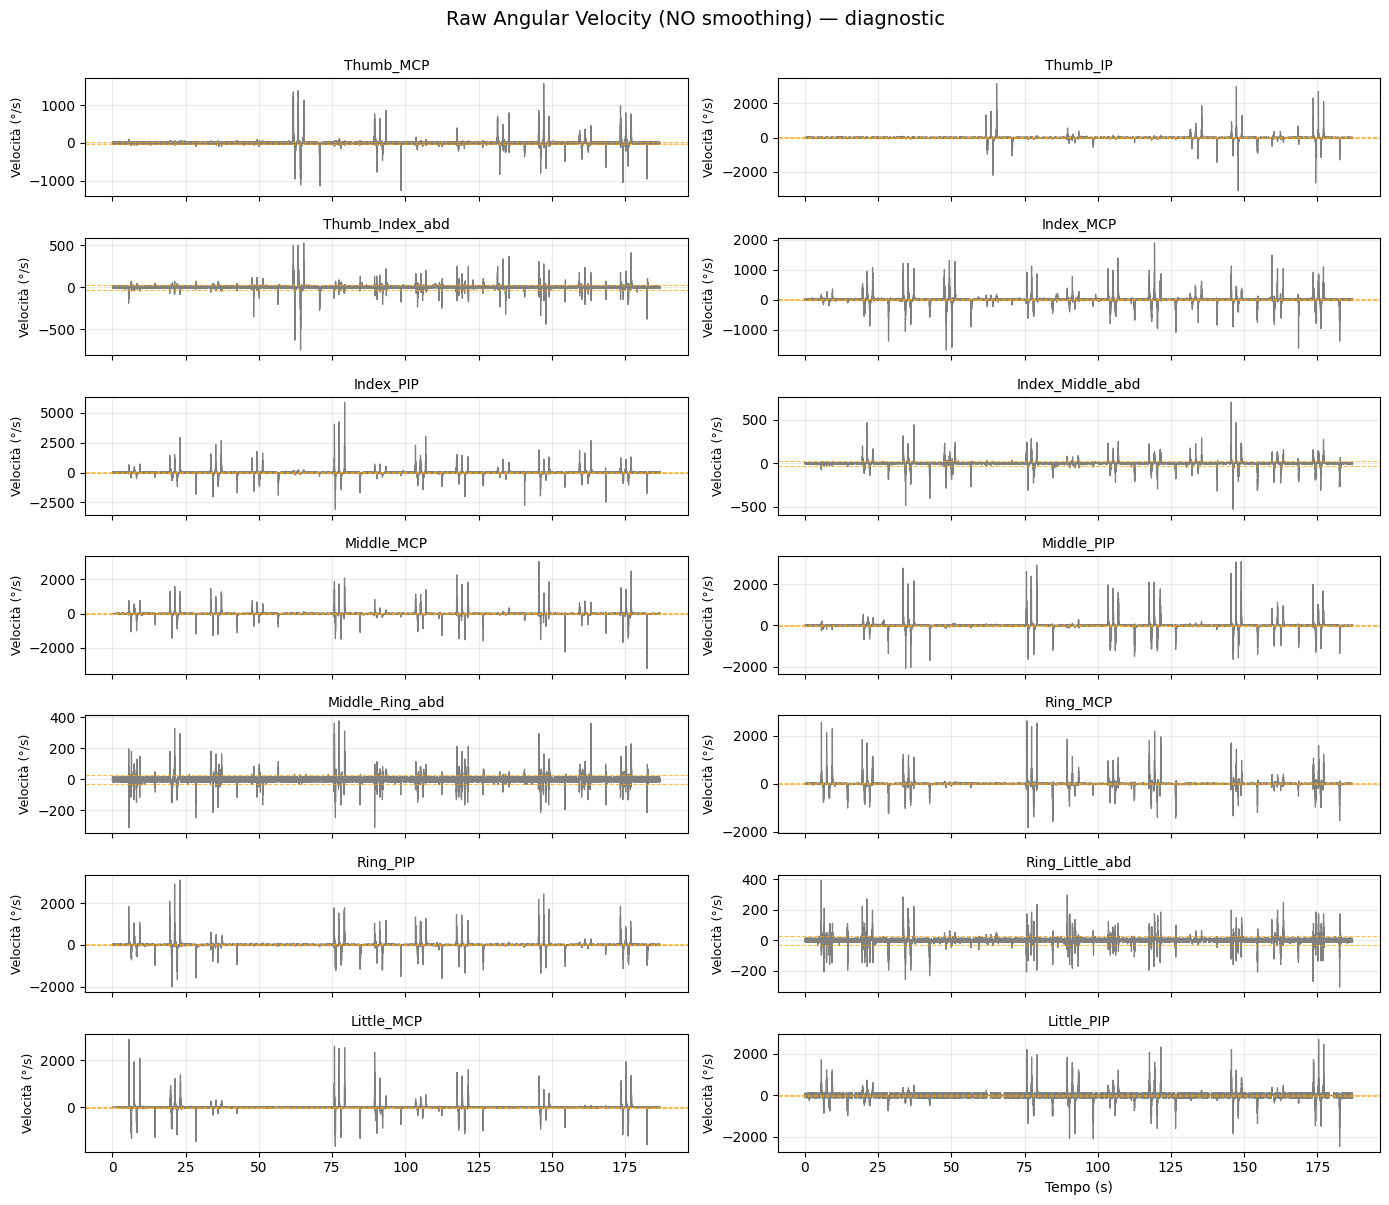

Per-channel peak absolute raw velocities (deg/s):
  Thumb_MCP         :  1561.22
  Thumb_IP          :  3149.38
  Thumb_Index_abd   :   750.00
  Index_MCP         :  1886.05
  Index_PIP         :  5876.29
  Index_Middle_abd  :   702.93
  Middle_MCP        :  3198.76
  Middle_PIP        :  3099.63
  Middle_Ring_abd   :   378.60
  Ring_MCP          :  2614.50
  Ring_PIP          :  3101.27
  Ring_Little_abd   :   395.06
  Little_MCP        :  2901.79
  Little_PIP        :  2696.77


In [6]:
# RAW ANGULAR VELOCITIES 
dt = 1.0 / fs
angles = unity_df[channel_names].values
raw_ang_vel = np.diff(angles, axis=0) / dt
time_vel = np.arange(raw_ang_vel.shape[0]) / fs

# Plot all channels
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
for ch in range(len(channel_names)):
    axes[ch].plot(time_vel, raw_ang_vel[:, ch], color='gray', linewidth=0.9)
    axes[ch].axhline(30.0, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[ch].axhline(-30.0, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[ch].set_title(channel_names[ch], fontsize=10)
    axes[ch].set_ylabel('Velocità (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.25)
axes[-1].set_xlabel('Tempo (s)', fontsize=10)
plt.suptitle('Raw Angular Velocity (NO smoothing) — diagnostic', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("Per-channel peak absolute raw velocities (deg/s):")
for i, name in enumerate(channel_names):
    print(f"  {name:18s}: {np.max(np.abs(raw_ang_vel[:, i])):8.2f}")

## Identify Isometric movements

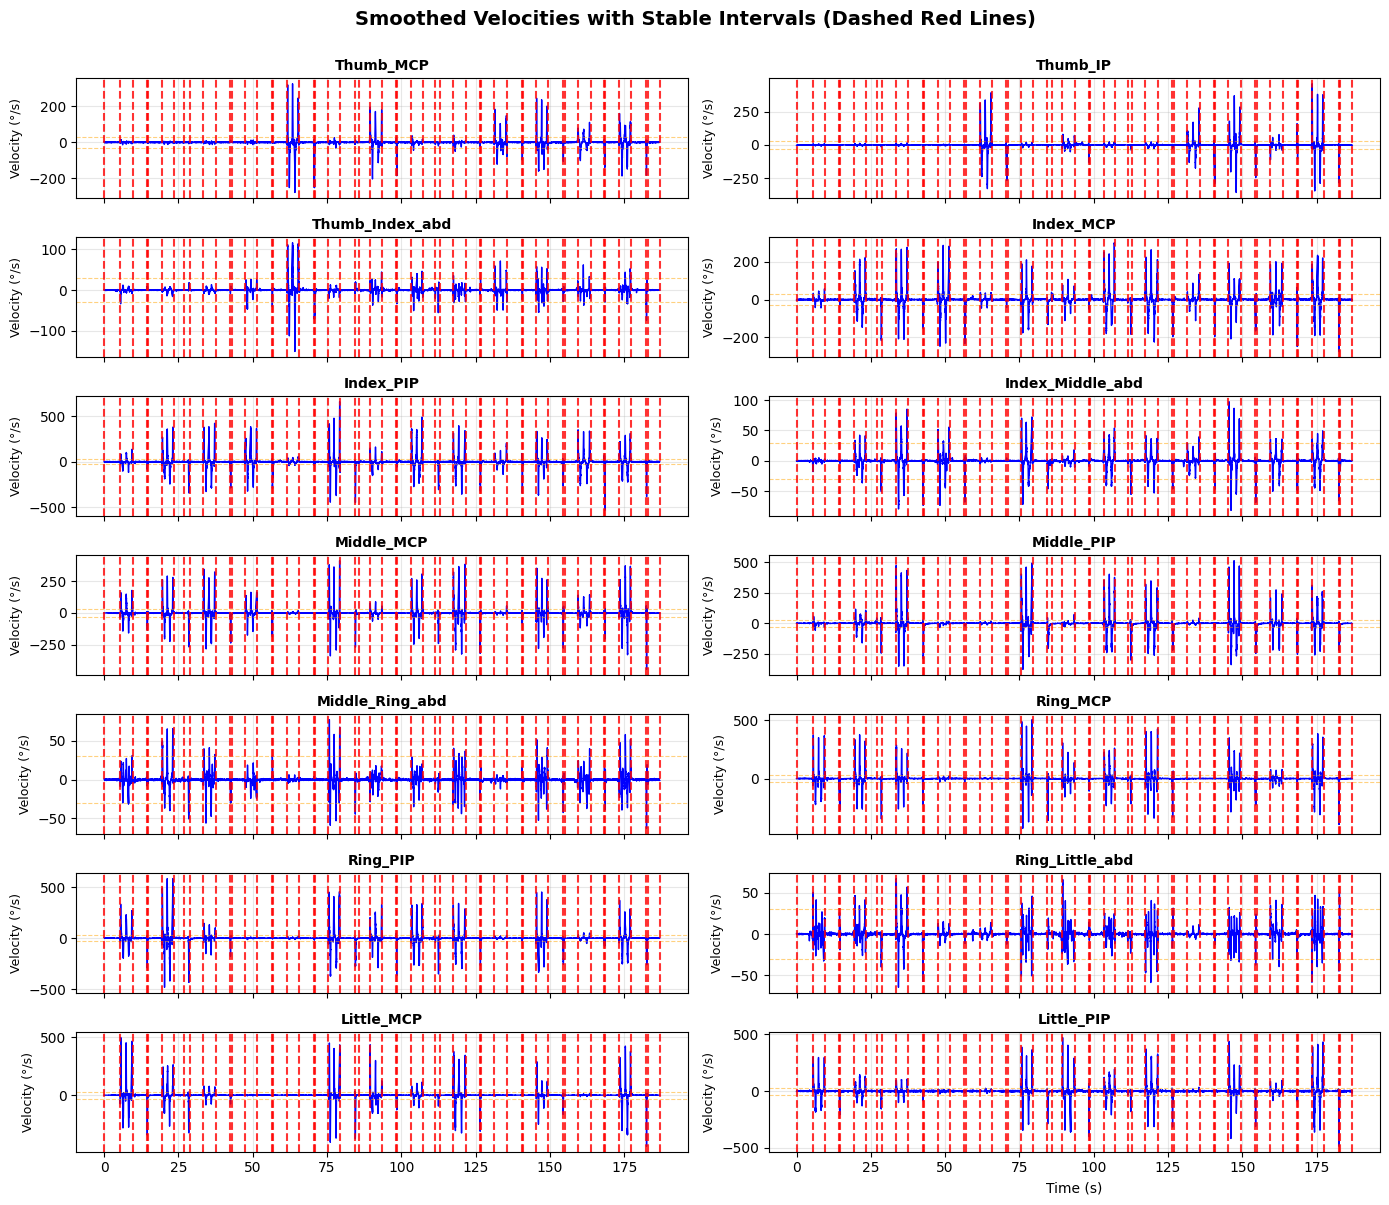


=== ISOMETRIC INTERVALS (velocity < 30.0°/s per ≥ 3.0s on all channels) ===

Periodo 1: 0.00s - 5.45s (duration: 5.45s)
Periodo 2: 9.60s - 14.38s (duration: 4.79s)
Periodo 3: 14.72s - 19.43s (duration: 4.71s)
Periodo 4: 23.43s - 26.93s (duration: 3.50s)
Periodo 5: 28.80s - 33.38s (duration: 4.58s)
Periodo 6: 37.65s - 42.44s (duration: 4.79s)
Periodo 7: 42.98s - 47.45s (duration: 4.48s)
Periodo 8: 51.50s - 56.52s (duration: 5.02s)
Periodo 9: 57.00s - 61.65s (duration: 4.65s)
Periodo 10: 65.61s - 70.62s (duration: 5.01s)
Periodo 11: 71.03s - 75.47s (duration: 4.44s)
Periodo 12: 79.44s - 84.37s (duration: 4.93s)
Periodo 13: 85.86s - 89.38s (duration: 3.52s)
Periodo 14: 93.67s - 98.31s (duration: 4.65s)
Periodo 15: 98.69s - 103.33s (duration: 4.64s)
Periodo 16: 107.31s - 111.42s (duration: 4.12s)
Periodo 17: 112.88s - 117.31s (duration: 4.43s)
Periodo 18: 121.67s - 126.39s (duration: 4.72s)
Periodo 19: 126.95s - 131.36s (duration: 4.41s)
Periodo 20: 135.63s - 140.53s (duration: 4.90s)
Per

In [7]:
# SMOOTHING 
dt = 1.0 / fs
velocity_threshold = 30.0  # °/s
min_stable_duration = 3.0  # seconds
min_stable_samples = int(min_stable_duration * fs)
polyorder = 3

angles = unity_df[channel_names].values  # shape (n_samples, 14)
n_samples = angles.shape[0]

# Odd window_length and <= n_samples
window_length = 51
if window_length >= n_samples:
    window_length = n_samples - 1 if (n_samples - 1) % 2 == 1 else n_samples - 2
if window_length < 3:
    window_length = 3
if window_length % 2 == 0:
    window_length += 1

# Smooth angles with Savitzky-Golay filter
smooth_angles = np.zeros_like(angles)
for i in range(angles.shape[1]):
    smooth_angles[:, i] = savgol_filter(angles[:, i], window_length, polyorder)

# Smoothed velocity in °/s
smooth_velocities = np.diff(smooth_angles, axis=0) / dt
time_vel = np.arange(smooth_velocities.shape[0]) / fs

# Identify stable samples (all channels with |v| < threshold)
is_stable_per_channel = np.abs(smooth_velocities) < velocity_threshold
is_stable_all = np.all(is_stable_per_channel, axis=1)

stable_periods = []
start_idx = None
for i, val in enumerate(is_stable_all):
    if val:
        if start_idx is None:
            start_idx = i
    else:
        if start_idx is not None and (i - start_idx) >= min_stable_samples:
            stable_periods.append((start_idx, i))
        start_idx = None
# Last check at the end of the loop
if start_idx is not None and (len(is_stable_all) - start_idx) >= min_stable_samples:
    stable_periods.append((start_idx, len(is_stable_all)))

# Plot: velocity and red dashed vertical lines at the start/end of stable intervals

fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ch in range(len(channel_names)):
    axes[ch].plot(time_vel, smooth_velocities[:, ch], linewidth=1, color='blue')
    axes[ch].axhline(y=velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ch].axhline(y=-velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    for start_idx, end_idx in stable_periods:
        axes[ch].axvline(x=time_vel[start_idx], color='red', linestyle='--', linewidth=1.5, alpha=0.8)
        axes[ch].axvline(x=time_vel[end_idx-1], color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    axes[ch].set_title(channel_names[ch], fontsize=10, fontweight='bold')
    axes[ch].set_ylabel('Velocity (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.suptitle('Smoothed Velocities with Stable Intervals (Dashed Red Lines)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


print(f"\n=== ISOMETRIC INTERVALS (velocity < {velocity_threshold}°/s per ≥ {min_stable_duration}s on all channels) ===\n")
if stable_periods:
    for i, (start_idx, end_idx) in enumerate(stable_periods):
        start_time = time_vel[start_idx]
        end_time = time_vel[end_idx-1]
        duration = end_time - start_time
        print(f"Periodo {i+1}: {start_time:.2f}s - {end_time:.2f}s (duration: {duration:.2f}s)")
else:
    print("No stable period found with the current criteria.")

print("\nParameters:")
print(f"  - Velocity threshold: {velocity_threshold}°/s")
print(f"  - Minimum duration: {min_stable_duration}s")
print(f"  - Smoothing: window {window_length} samples, polynomial order {polyorder}")

C:\Users\Charlie XD\AppData\Local\Temp\ipykernel_16548\3030944498.py:39: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


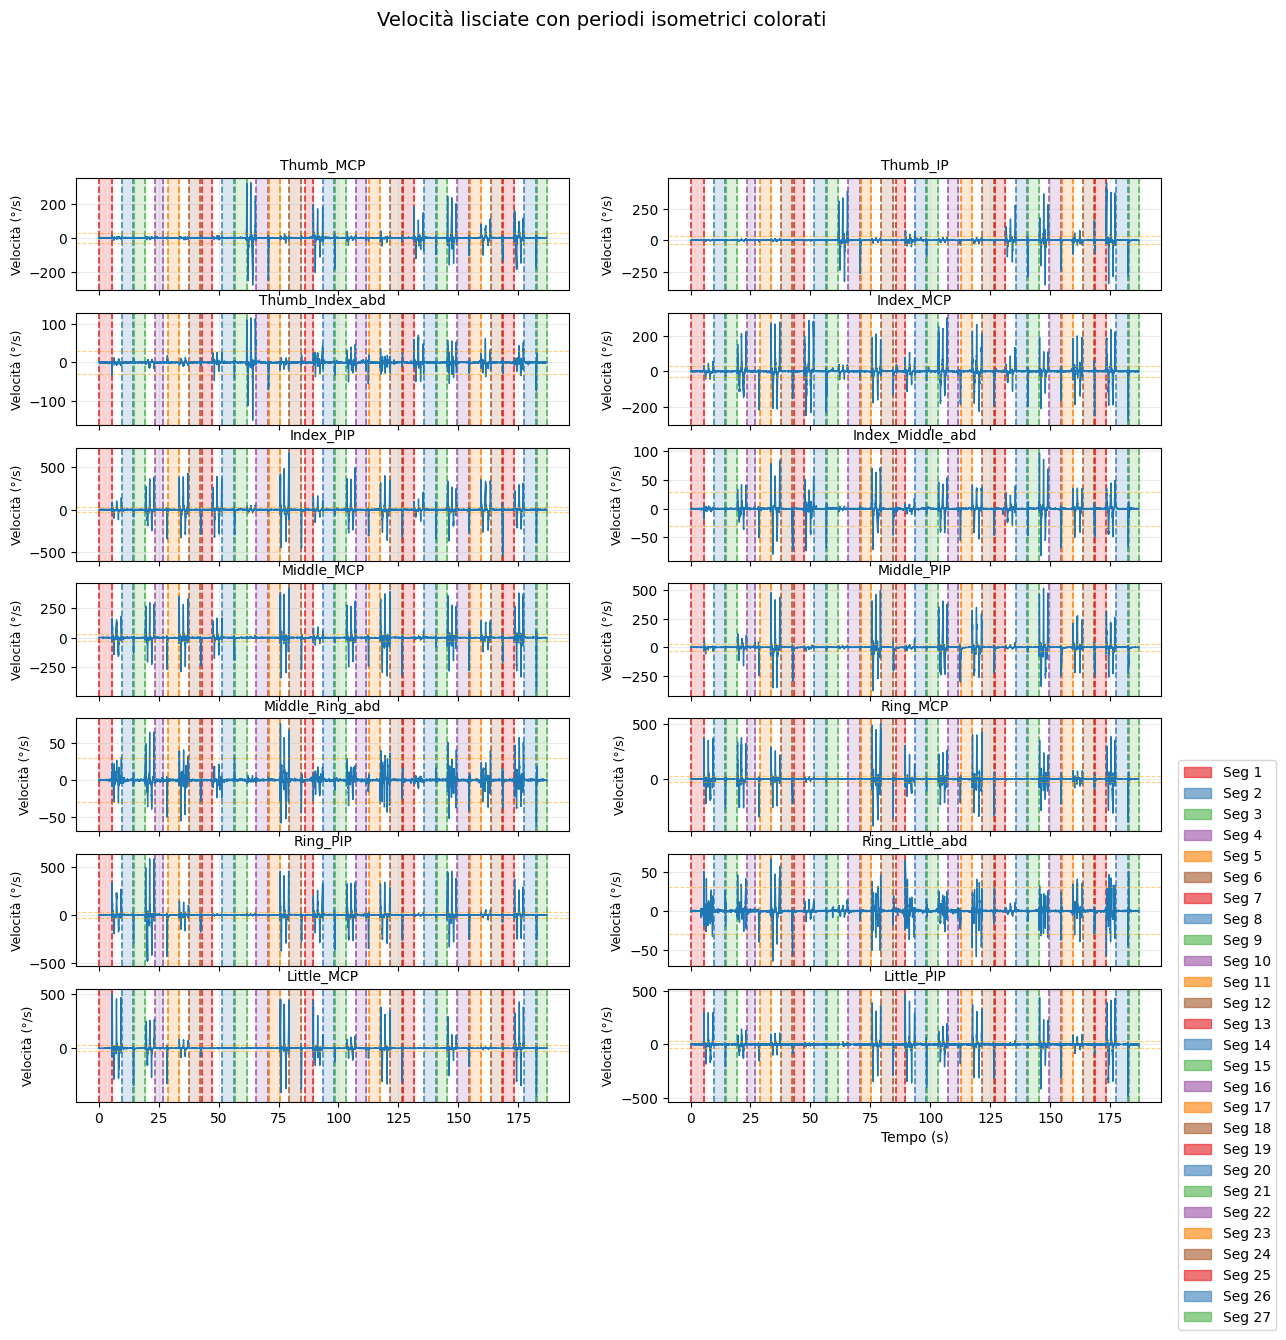

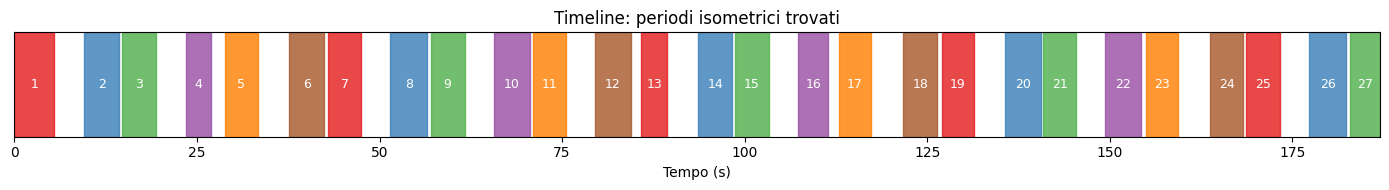

In [8]:
try:
    fs = fs
except NameError:
    fs = 200
dt = 1.0 / fs
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]  # palette
alpha_shade = 0.18
alpha_lines = 0.9

if 'smooth_velocities' not in globals() or 'time_vel' not in globals() or 'stable_periods' not in globals():
    raise RuntimeError("Compute first `smooth_velocities`, `time_vel` e `stable_periods`.")

# 1) Plot: channel-wise with colored areas (axvspan) and dashed lines at the borders
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
color_cycle = cycle(colors)
for idx, (start_idx, end_idx) in enumerate(stable_periods):
    c = colors[idx % len(colors)]
    start_t = time_vel[start_idx]
    end_t = time_vel[end_idx - 1]
    for ch in range(len(channel_names)):
        axes[ch].axvspan(start_t, end_t, color=c, alpha=alpha_shade)
        axes[ch].axvline(x=start_t, color=c, linestyle='--', linewidth=1.2, alpha=alpha_lines)
        axes[ch].axvline(x=end_t, color=c, linestyle='--', linewidth=1.2, alpha=alpha_lines)

for ch in range(len(channel_names)):
    axes[ch].plot(time_vel, smooth_velocities[:, ch], color='tab:blue', linewidth=1)
    axes[ch].axhline(y=velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ch].axhline(y=-velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ch].set_title(channel_names[ch], fontsize=10)
    axes[ch].set_ylabel('Velocità (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.25)

axes[-1].set_xlabel('Tempo (s)', fontsize=10)
plt.suptitle('Velocità lisciate con periodi isometrici colorati', fontsize=14, y=1.02)
# Legend for segments
legend_handles = [mpatches.Patch(color=colors[i % len(colors)], alpha=0.6, label=f"Seg {i+1}") for i in range(len(stable_periods))]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
plt.show()

# 2) Plot: segment division G
fig, ax = plt.subplots(figsize=(14, 2))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Tempo (s)')
ax.set_title('Timeline: periodi isometrici trovati')

for i, (start_idx, end_idx) in enumerate(stable_periods):
    start_t = time_vel[start_idx]
    end_t = time_vel[end_idx - 1]
    ax.axvspan(start_t, end_t, color=colors[i % len(colors)], alpha=0.8)
    ax.text((start_t + end_t) / 2, 0.5, f"{i+1}", ha='center', va='center', color='white', fontsize=9)

# full timeline limits (use time_vel or unity_df time)
t0 = 0.0
tmax = (unity_df.shape[0] - 1) / fs
ax.set_xlim(t0, tmax)
plt.tight_layout()
plt.show()


27 zone di cui 14 di rest e 13 di movimento. 
rest 1 movimento isometria 2, rest 3 movimento isometria 4, rest 5 viola movimento isometria 6 arancio, rest 7 marrone movimento isometria 8 rosso, rest 9 movimento 10, rest 11 movimento 12, rest 13 movimento 14, rest 15 movimento 16, rest 17 movimento 18, rest 19 moviemnto 20, rest 21 movimento 22, rest 23 movimento 24, rest 25 movimento 26, rest 27

In [9]:
# --- EMG record ---
emg_dir = Path(r"c:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\emg_sample_subj_01_trial_01")
emg_record_base = emg_dir / "hdkw_kin_exp03_subj01_1_emg"

rec_emg = wfdb.rdrecord(str(emg_record_base))
emg = rec_emg.p_signal
fs_emg = rec_emg.fs

print("EMG shape:", emg.shape)
print("EMG fs:", fs_emg)

# Use only the movement periods: 2, 4, 6, ...
movement_periods = [
    (zone_idx, start_idx, end_idx)
    for zone_idx, (start_idx, end_idx) in enumerate(stable_periods, start=1)
    if zone_idx % 2 == 0
]

print("Isometric Movement Periods:", len(movement_periods))

emg_segments = []
for zone_idx, start_idx, end_idx in movement_periods:
    t_start = time_vel[start_idx]
    t_end = time_vel[end_idx - 1]

    emg_start = int(round(t_start * fs_emg))
    emg_end = int(round(t_end * fs_emg))

    emg_start = max(0, emg_start)
    emg_end = min(emg.shape[0], emg_end)

    segment = emg[emg_start:emg_end, :]
    emg_segments.append({
        "zone": zone_idx,
        "t_start_s": t_start,
        "t_end_s": t_end,
        "emg_start": emg_start,
        "emg_end": emg_end,
        "samples": segment.shape[0],
        "data": segment
    })

    print(f"Zona {zone_idx}: {t_start:.2f}s - {t_end:.2f}s -> EMG [{emg_start}:{emg_end}] ({segment.shape[0]} campioni)")

for item in emg_segments:
    segment_df = pd.DataFrame(item["data"])
    out_path = emg_dir / f"emg_zone_{item['zone']:02d}.csv"
    segment_df.to_csv(out_path, index=False)

EMG shape: (374000, 448)
EMG fs: 2000
Isometric Movement Periods: 13
Zona 2: 9.60s - 14.38s -> EMG [19190:28770] (9580 campioni)
Zona 4: 23.43s - 26.93s -> EMG [46870:53870] (7000 campioni)
Zona 6: 37.65s - 42.44s -> EMG [75290:84880] (9590 campioni)
Zona 8: 51.50s - 56.52s -> EMG [103000:113030] (10030 campioni)
Zona 10: 65.61s - 70.62s -> EMG [131230:141250] (10020 campioni)
Zona 12: 79.44s - 84.37s -> EMG [158890:168740] (9850 campioni)
Zona 14: 93.67s - 98.31s -> EMG [187330:196630] (9300 campioni)
Zona 16: 107.31s - 111.42s -> EMG [214610:222850] (8240 campioni)
Zona 18: 121.67s - 126.39s -> EMG [243350:252790] (9440 campioni)
Zona 20: 135.63s - 140.53s -> EMG [271260:281060] (9800 campioni)
Zona 22: 149.40s - 154.33s -> EMG [298800:308660] (9860 campioni)
Zona 24: 163.68s - 168.30s -> EMG [327360:336600] (9240 campioni)
Zona 26: 177.34s - 182.41s -> EMG [354670:364810] (10140 campioni)


### Extract 1 movement 1 grid first 64 channels

In [10]:
# EXTRACT ONLY MOVEMENT PERIOD 20 (zone 20) as example TO DECOMPOSE LATER 
zone_20 = next(item for item in emg_segments if item["zone"] == 20)
segment_20 = zone_20["data"][:, -192:]

print("Zona:", zone_20["zone"])
print("Shape segmento 20:", segment_20.shape)
print("t_start_s:", zone_20["t_start_s"])
print("t_end_s:", zone_20["t_end_s"])
out_dir = Path(r"c:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_subj1_trial_1_10")
out_dir.mkdir(parents=True, exist_ok=True)

out_mat = out_dir / "subject01_trial1_zone20_raw.mat"

savemat(out_mat, {
    "emg_data": segment_20.T,  # channels x time
    "fs_emg": np.array([[float(fs_emg)]], dtype=np.float64),
    "trial": np.array([[1]], dtype=np.int32),
    "segment_id": np.array([[20]], dtype=np.int32),
    "t_start_s": np.array([[float(zone_20["t_start_s"])]], dtype=np.float64),
    "t_end_s": np.array([[float(zone_20["t_end_s"])]], dtype=np.float64),
}, do_compression=True)

print("Saved:", out_mat)

Zona: 20
Shape segmento 20: (9800, 192)
t_start_s: 135.63
t_end_s: 140.53
Saved: c:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_subj1_trial_1_10\subject01_trial1_zone20_raw.mat


In [12]:
# EXTRACT ONLY FIRST GRID (64 channels) OF MOVEMENT PERIOD 20 (zone 20) as example TO DECOMPOSE LATER
m = loadmat(str(out_mat))

# estrai emg_data e fs
#emg_data_ch_time = np.array(m['emg_data'])  # tu hai salvato channels x time
#emg_data = emg_data_ch_time.T  # trasponi a samples x channels

# estrai fs
fs_emg = float(np.squeeze(m['fs_emg']))

# estrai soli i primi 64 canali (prima griglia)
grid1 = segment_20[:, :64]

# Creo struct signal per muedit su matlab
# grid1 è già samples x 64, ma MUedit vuole channels x time, quindi si traspone
grid1_data = grid1.T  # -> 64 x samples

print(f"Grid1 data shape (channels x time): {grid1_data.shape}")

signal_struct = {
    "data": grid1_data.astype(np.float32),      # 64 x samples
    "fsamp": np.array([[2000]], dtype=np.float64), 
    "nchans": np.array([[64]], dtype=np.int32),
    "ngrid": np.array([[1]], dtype=np.int32),
    "ngrids": np.array([[1]], dtype=np.int32), 
    "nneedles": np.array([[0]], dtype=np.int32),
    "nelectrodes": np.array([[1]], dtype=np.int32),
    "electrodes": np.array(["GR10MM0808"], dtype=object),
    "muscles": np.array(["Forearm"], dtype=object),
    "gridname": np.array(["GR10MM0808"], dtype=object),
}

muedit_mat_path = Path(r"c:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_subj1_trial_1_10\signal_grid1_zone20_for_muedit.mat")
savemat(str(muedit_mat_path), {'signal': signal_struct}, do_compression=True)

print(f"Signal struct salvato: {muedit_mat_path}")

Grid1 data shape (channels x time): (64, 9800)
Signal struct salvato: c:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_subj1_trial_1_10\signal_grid1_zone20_for_muedit.mat


## ITERATE ON TRIALS SUBJECT01

In [13]:
# EMG data from each grip type was bandpass filtered so 
# that there was no difference in offset among different 
# recordings and the transitory part for the filtering was removed to avoid signal discontinuities.
# from Synergistic Organization of Neural Inputs from Spinal  Motor Neurons to Extrinsic and Intrinsic
# Hand Muscles by Simone Tanzarella et al.
def bandpass_emg(x, fs, low=20.0, high=500.0, order=4):
    nyq = fs / 2.0
    if high >= nyq:
        high = nyq * 0.95
    b, a = butter(order, [low / nyq, high / nyq], btype="bandpass")
    return filtfilt(b, a, x, axis=0)

# paper physionet says to do the notch at 50 Hz
def notch_emg(x, fs, f0=50.0, q=30.0):
    nyq = fs / 2.0
    if f0 >= nyq:
        return x
    b, a = iirnotch(f0 / nyq, q)
    return filtfilt(b, a, x, axis=0)

In [ ]:
subject01_dir = Path(r"C:\Users\Charlie XD\Documents\emg2mu\hdkw_kin-main\data\subject_01")
segment_mapping = {
    1: [20, 26],
    2: [20, 26],
    3: [20, 25],  # Different
    4: [18, 24],  # Different
    5: [20, 26],
    6: [20, 26]
}
all_segments = []
rows_meta = []
glove_segments = []
glove_rows_meta = []
for trial in range(1, 7):
    print(f"\n--- Trial {trial} ---")
    target_periods_1based = segment_mapping[trial] 
    glove_base = subject01_dir / f"hdkw_kin_exp03_subj01_{trial}_glove"
    emg_base = subject01_dir / f"hdkw_kin_exp03_subj01_{trial}_emg"

    # Load glove
    rec_glove = wfdb.rdrecord(str(glove_base))
    glove_data = rec_glove.p_signal
    fs_glove = 200

    # Mapping raw -> norm -> unity deg (come nel trial 1)
    raw_df_t = pd.DataFrame(glove_data, columns=channel_names)
    mins_t = raw_df_t[channel_names].min(axis=0)
    maxs_t = raw_df_t[channel_names].max(axis=0)
    ranges_t = (maxs_t - mins_t).replace(0, 1.0)

    norm_df_t = raw_df_t.copy()
    norm_df_t[channel_names] = (raw_df_t[channel_names] - mins_t) / ranges_t
    norm_df_t[channel_names] = norm_df_t[channel_names].clip(0.0, 1.0)

    unity_df_t = pd.DataFrame()
    for ch in channel_names:
        vals = norm_df_t[ch].values
        if ch in flexion_channels:
            deg = vals * flexion_channels[ch]
        elif ch in abduction_channels:
            deg = (vals - 0.5) * abduction_channels[ch]
        else:
            deg = vals * 90.0
        unity_df_t[ch] = sign_map[ch] * deg

    # Smooth + velocity + stable periods 
    dt_t = 1.0 / fs_glove
    angles_t = unity_df_t[channel_names].values
    n_samples_t = angles_t.shape[0]

    wl_t = 51
    if wl_t >= n_samples_t:
        wl_t = n_samples_t - 1 if (n_samples_t - 1) % 2 == 1 else n_samples_t - 2
    if wl_t < 3:
        wl_t = 3
    if wl_t % 2 == 0:
        wl_t += 1

    smooth_angles_t = np.zeros_like(angles_t)
    for i in range(angles_t.shape[1]):
        smooth_angles_t[:, i] = savgol_filter(angles_t[:, i], wl_t, polyorder)

    smooth_vel_t = np.diff(smooth_angles_t, axis=0) / dt_t
    time_vel_t = np.arange(smooth_vel_t.shape[0]) / fs_glove

    min_stable_samples_t = int(min_stable_duration * fs_glove)
    is_stable_all_t = np.all(np.abs(smooth_vel_t) < velocity_threshold, axis=1)

    stable_periods_t = []
    start_idx = None
    for i, val in enumerate(is_stable_all_t):
        if val and start_idx is None:
            start_idx = i
        elif (not val) and start_idx is not None:
            if (i - start_idx) >= min_stable_samples_t:
                stable_periods_t.append((start_idx, i))
            start_idx = None
    if start_idx is not None and (len(is_stable_all_t) - start_idx) >= min_stable_samples_t:
        stable_periods_t.append((start_idx, len(is_stable_all_t)))

    expected_segments = 27
    n_found = len(stable_periods_t)

    print(f"Found Periods: {n_found}")


    # Load EMG
    rec_emg_t = wfdb.rdrecord(str(emg_base))
    emg_t = rec_emg_t.p_signal
    fs_emg_t = rec_emg_t.fs
    # preprocessing sul trial completo
    emg_f = notch_emg(emg_t, fs_emg_t, f0=50.0, q=30.0)
    emg_f = bandpass_emg(emg_f, fs_emg_t, low=20.0, high=500.0, order=4)

    # rimozione transitorio ai bordi del trial filtrato
    edge_sec = 1.0
    edge_samples = int(round(edge_sec * fs_emg_t))
    if emg_f.shape[0] > 2 * edge_samples:
        emg_f = emg_f[edge_samples:-edge_samples, :]
    else:
        raise RuntimeError(f"Trial {trial}: troppo corto per rimuovere {edge_sec}s per lato.")

    # se tagli i bordi, anche l'origine temporale si sposta
    trial_time_shift = edge_samples / fs_emg_t
    # Only segment 20 and 26
    for seg_id in target_periods_1based:
        if seg_id <= len(stable_periods_t):
            s_idx, e_idx = stable_periods_t[seg_id - 1]
            t_start = time_vel_t[s_idx]
            t_end = time_vel_t[e_idx - 1]

            ## save glove segment for this period
            glove_start = int(round(t_start * fs_glove))
            glove_end = int(round(t_end * fs_glove))

            glove_start = max(0, glove_start)
            glove_end = min(unity_df_t.shape[0], glove_end)

            glove_seg = unity_df_t[channel_names].values[glove_start:glove_end, :]
            glove_segments.append(glove_seg)

            glove_rows_meta.append({
                "trial": trial,
                "segment_id": seg_id,
                "glove_start": glove_start,
                "glove_end": glove_end,
                "samples": glove_seg.shape[0]
            })
            
            ## save EMG segment for this period
            emg_start = int(round((t_start - trial_time_shift) * fs_emg_t))
            emg_end = int(round((t_end - trial_time_shift) * fs_emg_t))

            emg_start = max(0, emg_start)
            emg_end = min(emg_f.shape[0], emg_end)

            seg = emg_f[emg_start:emg_end, :]
            all_segments.append(seg)

            rows_meta.append({
                "trial": trial,
                "segment_id": seg_id,
                "t_start_s": t_start,
                "t_end_s": t_end,
                "emg_start": emg_start,
                "emg_end": emg_end,
                "samples": seg.shape[0]
            })

            print(f"  Segment {seg_id}: {seg.shape[0]} samples")
        else:
            print(f"  Segment {seg_id}: NOT FOUND")

# Concatenation
if len(all_segments) == 0:
    raise RuntimeError("There are no segments (20/26) in the processed trials.")

emg_concat = np.vstack(all_segments)
glove_concat = np.vstack(glove_segments)
print("\n=== FINAL CONCATENATED SIGNAL ===")
print("Shape:", emg_concat.shape)

# Save
out_dir = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_conc_subj1_trial_1_10_13")
out_dir.mkdir(parents=True, exist_ok=True)

out_csv = out_dir / "subject01_trials1to6_segments20_26_concatenated.csv"
meta_csv = out_dir / "subject01_trials1to6_segments20_26_metadata.csv"

pd.DataFrame(emg_concat).to_csv(out_csv, index=False)
pd.DataFrame(rows_meta).to_csv(meta_csv, index=False)

print("Saved:", out_csv)
print("Saved:", meta_csv)


--- Trial 1 ---
Found Periods: 27
  Segment 20: 9800 samples
  Segment 26: 10140 samples

--- Trial 2 ---
Found Periods: 27
  Segment 20: 10460 samples
  Segment 26: 9640 samples

--- Trial 3 ---
Found Periods: 26
  Segment 20: 10120 samples
  Segment 25: 9730 samples

--- Trial 4 ---
Found Periods: 25
  Segment 18: 9440 samples
  Segment 24: 10160 samples

--- Trial 5 ---
Found Periods: 27
  Segment 20: 9700 samples
  Segment 26: 10100 samples

--- Trial 6 ---
Found Periods: 26


In [14]:
out_dir = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_conc_subj1_trial_1_10_13")
emg_csv = out_dir / "subject01_trials1to6_segments20_26_concatenated.csv"
meta_csv = out_dir / "subject01_trials1to6_segments20_26_metadata.csv"

emg_concat = pd.read_csv(emg_csv).values        # shape (samples, channels)
rows_meta = pd.read_csv(meta_csv).to_dict(orient="records")

emg_channel_names = np.array([f"EMG{i+1}" for i in range(emg_concat.shape[1])], dtype=object)

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.io import savemat
import wfdb

out_dir = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_conc_subj1_trial_1_10_13")
emg_csv = out_dir / "subject01_trials1to6_segments20_26_concatenated.csv"
meta_csv = out_dir / "subject01_trials1to6_segments20_26_metadata.csv"
glove_csv = out_dir / "subject01_trials1to6_segments20_26_glove_concatenated.csv"
glove_meta_csv = out_dir / "subject01_trials1to6_segments20_26_glove_metadata.csv"

# existence checks
if not emg_csv.exists() or not meta_csv.exists():
    raise FileNotFoundError(f"Missing CSVs. Expected: {emg_csv} and {meta_csv}")

# load
emg_concat = pd.read_csv(emg_csv).values.astype(np.float32)   # (samples, channels) expected
rows_meta = pd.read_csv(meta_csv).to_dict(orient="records")

# Fix orientation if needed (some code paths produced transposed CSVs)
if emg_concat.shape[0] < emg_concat.shape[1]:
    emg_concat = emg_concat.T

# try load glove if present
glove_concat = None
glove_rows_meta = None
if glove_csv.exists():
    glove_concat = pd.read_csv(glove_csv).values.astype(np.float32)
    if glove_meta_csv.exists():
        glove_rows_meta = pd.read_csv(glove_meta_csv).to_dict(orient="records")

# determine EMG sampling freq and channel names from a WFDB record if available
fs_emg_t = None
emg_channel_names = None
subject_emg_dir = Path(r"C:\Users\Charlie XD\Documents\emg2mu\hdkw_kin-main\data\subject_01")
try:
    hea = next(subject_emg_dir.glob("*_emg.hea"))
    base = hea.with_suffix("")  # rdrecord wants base name without extension
    rec = wfdb.rdrecord(str(base))
    fs_emg_t = float(rec.fs)
    emg_channel_names = np.array(list(rec.sig_name), dtype=object)
except StopIteration:
    pass
except Exception:
    pass

# fallback if not found
if fs_emg_t is None:
    # set manually if you know it (else change this)
    fs_emg_t = 200.0

if emg_channel_names is None:
    emg_channel_names = np.array([f"EMG{i+1}" for i in range(emg_concat.shape[1])], dtype=object)

# glove channel names fallback
if glove_concat is not None:
    # try to reuse `channel_names` from notebook globals if present
    if 'channel_names' in globals():
        glove_channel_names = np.array(channel_names, dtype=object)
    else:
        glove_channel_names = np.array([f"Glove{i+1}" for i in range(glove_concat.shape[1])], dtype=object)
else:
    glove_channel_names = np.array([], dtype=object)

# build segment metadata arrays (safe access)
segment_bounds_emg = np.array([[int(r.get("emg_start", 0)), int(r.get("emg_end", 0))] for r in rows_meta], dtype=np.int32)
if glove_rows_meta is not None:
    segment_bounds_glove = np.array([[int(r.get("glove_start", 0)), int(r.get("glove_end", 0))] for r in glove_rows_meta], dtype=np.int32)
else:
    segment_bounds_glove = np.empty((0,2), dtype=np.int32)

segment_labels = np.array([f"trial{int(r.get('trial',0))}_seg{int(r.get('segment_id',0))}" for r in rows_meta], dtype=object)
segment_trials = np.array([int(r.get("trial", 0)) for r in rows_meta], dtype=np.int32)

# final mat dict (emg_data: samples x channels)
mat_data = {
    "emg_data": emg_concat,
    "fs_emg": np.array([[float(fs_emg_t)]], dtype=np.float64),
    "emg_channel_names": emg_channel_names,
    "segment_bounds_emg": segment_bounds_emg,
    "segment_labels": segment_labels,
    "segment_trials": segment_trials,
    "units_emg": np.array(["uV"], dtype=object),
}

# add glove if available
if glove_concat is not None and glove_concat.size:
    mat_data.update({
        "glove_data": glove_concat,
        "fs_glove": np.array([[200.0]], dtype=np.float64),
        "glove_channel_names": glove_channel_names,
        "segment_bounds_glove": segment_bounds_glove,
        "units_glove": np.array(["deg"], dtype=object),
    })

out_mat = out_dir / "subject01_concat.mat"
savemat(out_mat, mat_data, do_compression=True)
print("Saved:", out_mat)

Saved: C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_conc_subj1_trial_1_10_13\subject01_concat.mat


In [33]:
def open_mat(self, inputfile):
        """
        Load a MATLAB .mat created by the notebook and map it to self.signal_dict.
        This version is tailored for your 3-grid HD sEMG setup:
        3 x GR10MM0808, 192 channels total.
        """
        from scipy.io import loadmat

        mat = loadmat(inputfile, struct_as_record=False, squeeze_me=True)

        if 'emg_data' in mat:
            emg = np.asarray(mat['emg_data'])
        elif 'data' in mat:
            emg = np.asarray(mat['data'])
        else:
            raise RuntimeError("MAT file missing 'emg_data' or 'data' variables.")

        if emg.ndim != 2:
            raise RuntimeError(f"EMG array must be 2D, found ndim={emg.ndim}")

        # Keep data as (channels, samples)
        # If it was saved as (samples, channels), transpose it.
        if emg.shape[0] != 192 and emg.shape[1] == 192:
            emg = emg.T

        if emg.shape[0] != 192:
            raise RuntimeError(f"Expected 192 EMG channels, found {emg.shape[0]}.")

        nchans = emg.shape[0]

        fsamp = None
        if 'fs_emg' in mat:
            try:
                fsamp = float(np.squeeze(mat['fs_emg']))
            except Exception:
                pass
        if fsamp is None and 'fs' in mat:
            try:
                fsamp = float(np.squeeze(mat['fs']))
            except Exception:
                pass
        if fsamp is None:
            raise RuntimeError("Sampling frequency not found in .mat (expected 'fs_emg' or 'fs').")

        ngrids = 3
        nneedles = 0
        nelectrodes = 3
        electrodes = ['GR10MM0808'] * 3

        if 'muscles' in mat:
            muscles = np.atleast_1d(mat['muscles']).astype(object).tolist()
            if len(muscles) < nelectrodes:
                muscles = muscles + ['GR10MM0808'] * (nelectrodes - len(muscles))
            else:
                muscles = muscles[:nelectrodes]
        else:
            muscles = ['GR10MM0808'] * 3

        signal = dict(
            data=emg.astype(float),
            fsamp=int(fsamp),
            nchans=nchans,
            ngrids=ngrids,
            nneedles=nneedles,
            nelectrodes=nelectrodes,
            electrodes=electrodes,
            muscles=muscles
        )

        if 'path' in mat:
            signal['path'] = np.squeeze(mat['path']).astype(float)
        if 'target' in mat:
            signal['target'] = np.squeeze(mat['target']).astype(float)

        self.signal_dict = signal
        self.decomp_dict = {}
        self.mu_dict = dict(pulse_trains=[], discharge_times=[[] for _ in range(1)])

        return

In [36]:
from scipy.io import loadmat
import numpy as np
from pathlib import Path

path_to_mat = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\data_conc_subj1_trial_1_10_13\subject01_concat.mat")
m = loadmat(str(path_to_mat), struct_as_record=False, squeeze_me=True)
emg = np.asarray(m.get('emg_data', m.get('data')))

# if saved as (samples, channels) -> transpose
if emg.ndim == 2 and emg.shape[0] > emg.shape[1]:
    emg = emg.T

# keep only first 192 channels (3 x 8x8 grids)
if emg.shape[0] >= 192:
    emg = emg[:192, :]
else:
    raise RuntimeError(f"Too few channels: found {emg.shape[0]}")

print("data.shape (channels, samples):", emg.shape)
print("fs_emg:", np.squeeze(m.get('fs_emg', m.get('fs', None))))

data.shape (channels, samples): (192, 122140)
fs_emg: 2000.0
